# HF Transformer: online next-minute direction for SPY, QQQ, IWM

**Forecast.** At the instant a 1-minute bar has completed, output three numbers in $[0,1]^3$:
$[P(C_{SPY,t+1}>C_{SPY,t}), P(C_{QQQ,t+1}>C_{QQQ,t}), P(C_{IWM,t+1}>C_{IWM,t})]$.
An unchanged next close is counted as **not up**. Alpaca timestamps a bar by its *start*: the 09:30 bar completes around 09:31, the model predicts then, and its outcome is known around 09:32.

This project uses the existing adjusted Alpaca SIP snapshots in `SP500/attention_data` (daily) and `SP500/minute_data` (1-minute). The notebook replays historical arrivals in time order; it does not place orders. It trains a probability model online using Brier loss, with **one weight update after each newly revealed next-minute outcome**.

## 1. Inputs and leakage boundary

Two Transformer encoders read (1) the most recent `daily_window` completed sessions **before the current day** and (2) up to `minute_window` completed bars **from the current day through the decision bar**. Both streams carry SPY, QQQ and IWM together. Daily tokens contain adjusted close-to-close, overnight and intraday returns (9 features). Minute tokens contain close-to-previous-close and close-to-open returns (6 features), plus time-of-day sine/cosine (2 features). Fixed return scales prevent future-statistic normalization.

Each encoder uses causal self-attention and learned age embeddings. Its final token is combined with the other stream to produce three sigmoid probabilities. A minute pair is used only when the three ETFs have aligned bars exactly one minute apart. Missing bars and overnight transitions are never labeled by forward filling.

Install into the selected kernel with `python -m pip install -r HF_Transformer/requirements.txt` if needed. The supplied `Quant_ENV` environment was used for the executed notebook.

In [1]:
from pathlib import Path
import json, sys
import numpy as np
import pandas as pd
from IPython.display import display

cwd = Path.cwd()
if (cwd / 'HF_Transformer' / 'online_transformer.py').exists():
    project = cwd
elif cwd.name == 'HF_Transformer' and (cwd / 'online_transformer.py').exists():
    project = cwd.parent
else:
    raise RuntimeError('Start Jupyter in the project root or HF_Transformer directory.')
sys.path.insert(0, str(project / 'SP500'))
sys.path.insert(0, str(project / 'HF_Transformer'))
from etf_attention_rl import load_etf_csvs
from etf_minute_attention_rl import load_minute_bars
from online_transformer import (SYMBOLS, Settings, make_sessions, run_replay,
                                score_predictions, OnlineAgent, StreamingTrainer,
                                current_context)

output_dir = project / 'HF_Transformer' / 'outputs'
daily_dir = project / 'SP500' / 'attention_data'
minute_dir = project / 'SP500' / 'minute_data'


In [2]:
daily_dates, daily_prices = load_etf_csvs(daily_dir)
minute_bars = load_minute_bars(minute_dir)
daily_tokens, all_sessions = make_sessions(daily_dates, daily_prices, minute_bars)

# Runtime control: use the latest 60 sessions for the executed example.
# Increase this toward len(all_sessions) to train on more of the 2016-2026 archive.
replay_sessions = 600
sessions = all_sessions[-replay_sessions:]
print(f'Archive: {len(all_sessions):,} eligible sessions; replay: {len(sessions)} sessions')
print('Replay dates:', sessions[0].date.date(), 'to', sessions[-1].date.date())
print('Next-minute labels per ETF:', sum(len(s.labels) for s in sessions))
print('Available prior daily sessions for first replay day:', sessions[0].daily_end)


Archive: 2,694 eligible sessions; replay: 600 sessions
Replay dates: 2024-05-06 to 2026-09-25
Next-minute labels per ETF: 232598
Available prior daily sessions for first replay day: 2098


## 2. Training and test process

Sessions are split chronologically: 70% train, 15% frozen validation, 15% test. The model predicts **before** seeing each next-minute close. Once that close arrives, it takes one AdamW/Brier gradient step before the next eligible forecast. Validation makes no updates. The test period reports both a frozen copy of the trained model and the continuing online model; neither test stream changes the other. The outputs include exact forecast and outcome-availability times.

`daily_window` and `minute_window` determine the visible history and attention cost. `width`, `heads`, `layers` and `learning_rate` control capacity and adaptation. Larger `replay_sessions` improves historical coverage but increases runtime roughly in proportion to the number of minute labels. The default 60-session replay is a runnable demonstration, not evidence of a trading edge.

In [3]:
cfg = Settings(seed=42, daily_window=32, minute_window=24,
               width=16, heads=4, layers=1, learning_rate=1e-4,
               train_fraction=.5, validation_fraction=.15)
result = run_replay(daily_tokens, sessions, cfg, verbose=True)
predictions = result['predictions']
metrics = score_predictions(predictions)
output_dir.mkdir(parents=True, exist_ok=True)
predictions.to_csv(output_dir / 'predictions.csv', index=False)
metrics.to_csv(output_dir / 'metrics.csv', index=False)
checkpoint = output_dir / 'online_checkpoint.pt'
result['online_agent'].save(checkpoint)
run_info = {'settings': cfg.__dict__, 'replay_sessions': len(sessions),
            'replay_start': str(sessions[0].date.date()),
            'replay_end': str(sessions[-1].date.date()),
            'labels_per_etf': sum(len(s.labels) for s in sessions),
            'split_sessions': result['split_sessions'],
            'split_dates': result['split_dates'],
            'train_updates': result['frozen_agent'].updates,
            'online_updates_total': result['online_agent'].updates}
(output_dir / 'run_info.json').write_text(json.dumps(run_info, indent=2) + chr(10), encoding='utf-8')
print(run_info)


Trained 10/300 sessions
Trained 20/300 sessions
Trained 30/300 sessions
Trained 40/300 sessions
Trained 50/300 sessions
Trained 60/300 sessions
Trained 70/300 sessions
Trained 80/300 sessions
Trained 90/300 sessions
Trained 100/300 sessions
Trained 110/300 sessions
Trained 120/300 sessions
Trained 130/300 sessions
Trained 140/300 sessions
Trained 150/300 sessions
Trained 160/300 sessions
Trained 170/300 sessions
Trained 180/300 sessions
Trained 190/300 sessions
Trained 200/300 sessions
Trained 210/300 sessions
Trained 220/300 sessions
Trained 230/300 sessions
Trained 240/300 sessions
Trained 250/300 sessions
Trained 260/300 sessions
Trained 270/300 sessions
Trained 280/300 sessions
Trained 290/300 sessions
Trained 300/300 sessions
{'settings': {'seed': 42, 'daily_window': 32, 'minute_window': 24, 'width': 16, 'heads': 4, 'layers': 1, 'learning_rate': 0.0001, 'train_fraction': 0.5, 'validation_fraction': 0.15}, 'replay_sessions': 600, 'replay_start': '2024-05-06', 'replay_end': '2026-09

In [4]:
# Accuracy uses p >= 0.5 to call "up". Brier is a probability score (lower is better).
display(metrics.sort_values(['split', 'version', 'symbol']).round(4).reset_index(drop=True))


,split,version,symbol,n,accuracy_at_half,brier,up_rate
0,test,frozen,IWM,81417,0.5058,0.2499,0.4783
1,test,frozen,QQQ,81417,0.5010,0.2500,0.4937
2,test,frozen,SPY,81417,0.5110,0.2499,0.4879
3,test,online,IWM,81417,0.5203,0.2495,0.4783
4,test,online,QQQ,81417,0.5062,0.2500,0.4937
5,test,online,SPY,81417,0.5112,0.2499,0.4879
6,train,online,IWM,116171,0.5143,0.2498,0.4811
7,train,online,QQQ,116171,0.5057,0.2501,0.4961
8,train,online,SPY,116171,0.5063,0.2500,0.4932
9,validation,frozen,IWM,35010,0.5081,0.2499,0.4805


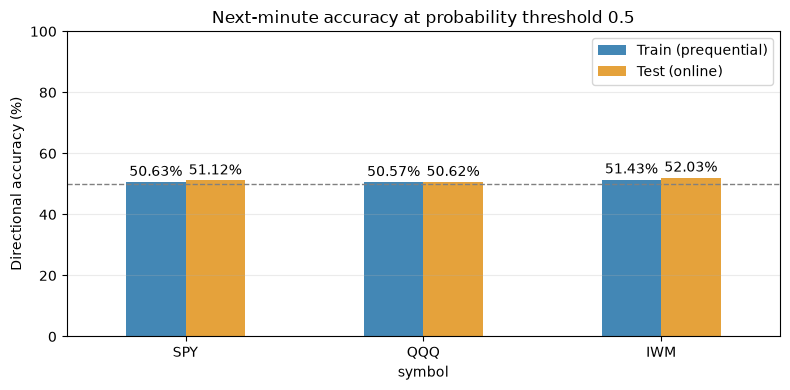

In [5]:
import os
plot_cache = output_dir / '.matplotlib_cache'
plot_cache.mkdir(parents=True, exist_ok=True)
os.environ.setdefault('MPLCONFIGDIR', str(plot_cache))
import matplotlib.pyplot as plt

train_accuracy = metrics.query("split == 'train' and version == 'online'").set_index('symbol')['accuracy_at_half']
test_accuracy = metrics.query("split == 'test' and version == 'online'").set_index('symbol')['accuracy_at_half']
accuracy = pd.DataFrame({'Train (prequential)': train_accuracy,
                         'Test (online)': test_accuracy}).loc[list(SYMBOLS)] * 100
ax = accuracy.plot.bar(figsize=(8, 4), rot=0, color=['#4387B5', '#E5A23B'])
ax.axhline(50, color='gray', linestyle='--', linewidth=1)
ax.set_ylabel('Directional accuracy (%)')
ax.set_title('Next-minute accuracy at probability threshold 0.5')
ax.set_ylim(0, 100)
ax.grid(axis='y', alpha=.25)
for bars in ax.containers:
    ax.bar_label(bars, fmt='%.2f%%', padding=2)
plt.tight_layout()
plt.savefig(output_dir / 'train_test_accuracy.png', dpi=150)
plt.show()


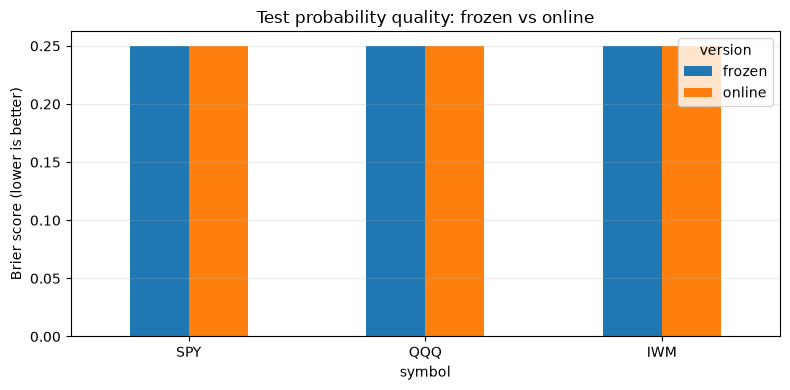

In [6]:
test_brier = (metrics.query("split == 'test'")
              .pivot(index='symbol', columns='version', values='brier')
              .loc[list(SYMBOLS)])
ax = test_brier[['frozen', 'online']].plot.bar(figsize=(8, 4), rot=0)
ax.set_ylabel('Brier score (lower is better)')
ax.set_title('Test probability quality: frozen vs online')
ax.grid(axis='y', alpha=.25)
plt.tight_layout()
plt.savefig(output_dir / 'test_brier.png', dpi=150)
plt.show()


## 3. Using new bars after the replay

The saved checkpoint includes model **and optimizer** state, so adaptation can continue. In a live process, collect all three ETFs' completed bars for the current session, using the same adjusted basis and SIP feed as training. `current_context` excludes today's daily bar and includes the latest completed minute bar. Call `StreamingTrainer.on_completed_bar` once per newly completed aligned bar. It first settles the prior forecast if the bars are consecutive, updates the weights with that observed label, then returns a new $[0,1]^3$ forecast. A gap discards the pending label. Never pass a still-forming minute bar.

The next cell demonstrates the update mechanism with a **copy** of the trained agent and two historical bars. It does not alter the saved checkpoint or any reported test metric.

In [7]:
from copy import deepcopy
example_agent = deepcopy(result['online_agent'])
stream = StreamingTrainer(example_agent)
last_session_date = sessions[-1].date.date()
ny_dates = minute_bars.index.tz_convert('America/New_York').date
example_day = minute_bars[ny_dates == last_session_date].iloc[:2]
first_context = current_context(daily_dates, daily_prices, example_day.iloc[:1], cfg)
first_probability, first_updated = stream.on_completed_bar(*first_context)
second_context = current_context(daily_dates, daily_prices, example_day, cfg)
second_probability, second_updated = stream.on_completed_bar(*second_context)
print('First forecast:', dict(zip(SYMBOLS, first_probability.round(4))), 'updated:', first_updated)
print('After next bar:', dict(zip(SYMBOLS, second_probability.round(4))), 'updated:', second_updated)
print('Updates in demonstration copy:', example_agent.updates - result['online_agent'].updates)


First forecast: {'SPY': 0.4953, 'QQQ': 0.4941, 'IWM': 0.4662} updated: False
After next bar: {'SPY': 0.4958, 'QQQ': 0.4975, 'IWM': 0.4699} updated: True
Updates in demonstration copy: 1


## 4. Interpretation and tuning

The saved `predictions.csv` contains every train, validation, frozen-test and online-test forecast in this replay. `metrics.csv` summarizes accuracy at 0.5 and Brier score, and `online_checkpoint.pt` can resume online learning. Inspect training and test together: a large gap may signal overfitting or regime change. Because the three ETFs and adjacent minutes are correlated, minute rows are not independent trials. A 50% reference line is shown for orientation; compare against class-frequency and cost-aware baselines before drawing a trading conclusion. Spread, fees, latency and live feed delays are not modeled here.

Useful experiments: increase `replay_sessions`, vary `daily_window` and `minute_window`, compare learning rates, and hold out later dates. Keep the same chronological split when comparing settings. Changing the probability threshold changes *directional decisions*, not the model's underlying probability quality; inspect Brier and calibration as well as accuracy.